(1296675, 23)
(555719, 23)


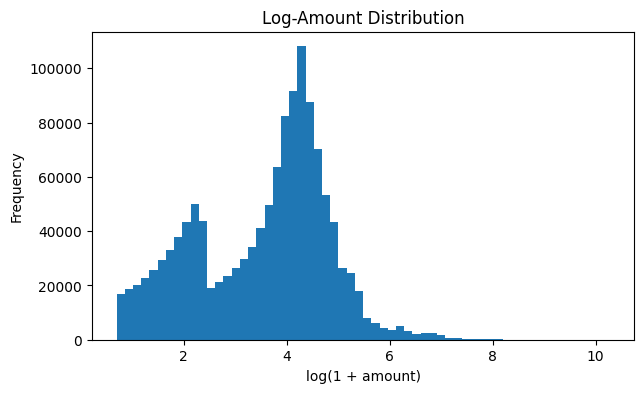

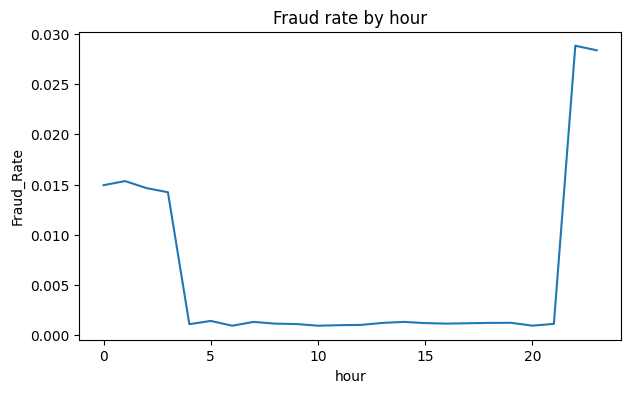

,is_fraud
category,
shopping_net,0.017561
misc_net,0.014458
grocery_pos,0.014098
shopping_pos,0.007225
gas_transport,0.004694
misc_pos,0.003139
grocery_net,0.002948
travel,0.002864
entertainment,0.002478


In [28]:
import pandas as pd
df_train = pd.read_csv("/content/drive/MyDrive/fraudTrain.csv")
df_test = pd.read_csv("/content/drive/MyDrive/fraudTest.csv")
print(df_train.shape)
print(df_test.shape)

df_train.head()
df_test.head()

df_train.isna().sum()
df_test.isna().sum()

df_train.describe()
df_test.describe()

df_train['is_fraud'].value_counts()
df_train['is_fraud'].value_counts(normalize=True)

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize= (7,4))
plt.hist(np.log1p(df_train['amt']), bins=60)
plt.title("Log-Amount Distribution")
plt.xlabel("log(1 + amount)")
plt.ylabel("Frequency")
plt.show()

df_train.groupby('is_fraud')['amt'].describe()

df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['hour'] = df_train['trans_date_trans_time'].dt.hour

df_train.groupby('hour')['is_fraud'].mean().plot(
    figsize =(7,4), title="Fraud rate by hour"
)
plt.ylabel("Fraud_Rate")
plt.show()

merchant_stats = (
    df_train.groupby('merchant')['is_fraud']
    .agg(['count','mean'])
    .sort_values('mean', ascending=False)
)

merchant_stats.head(10)

df_train.groupby('gender')['is_fraud'].mean()
df_train.groupby('category')['is_fraud'].mean().sort_values(ascending=False)



In [3]:
drop_cols = [
    'Unnamed: 0',
    'first', 'last',
    'city', 'street', 'zip',
    'trans_num'
]
df_train_clean = df_train.drop(columns=drop_cols)
df_test_clean = df_test.drop(columns=drop_cols)

df_train_clean.shape, df_test_clean.shape

((1296675, 17), (555719, 16))

In [4]:
df_train_clean.columns
df_test_clean.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'state', 'lat', 'long', 'city_pop', 'job', 'dob', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [5]:
df_train.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'hour'],
      dtype='object')

In [6]:
df_train_clean['dob'] = pd.to_datetime(df_train_clean['dob'])
df_test_clean['dob'] = pd.to_datetime(df_test_clean['dob'])

df_train_clean['trans_date_trans_time'] = pd.to_datetime(df_train_clean['trans_date_trans_time'])
df_test_clean['trans_date_trans_time'] = pd.to_datetime(df_test_clean['trans_date_trans_time'])

df_train_clean['cc_num'] = df_train_clean['cc_num'].astype(str)
df_test_clean['cc_num'] = df_test_clean['cc_num'].astype(str)

In [7]:
df_train_clean['age'] = (
    df_train_clean['trans_date_trans_time'] - df_train_clean['dob']
).dt.days // 365

df_test_clean['age'] = (
    df_test_clean['trans_date_trans_time'] - df_test_clean['dob']
).dt.days // 365

In [8]:
import numpy as np
df_train_clean['log_amt'] = np.log1p(df_train_clean['amt'])
df_test_clean['log_amt'] = np.log1p(df_test_clean['amt'])


In [9]:
cust_features = (
    df_train_clean.groupby('cc_num')['amt']
    .agg(
        cust_txn_count = 'count',
        cust_avg_amt = 'mean',
        cust_std_amt = 'std'
    )
)

df_train_clean = df_train_clean.merge(cust_features, on='cc_num', how='left')
df_test_clean = df_test_clean.merge(cust_features, on='cc_num', how='left')


In [10]:
df_train_clean['amt_vs_cust_avg'] = (
    df_train_clean['amt'] / (df_train_clean['cust_avg_amt'] + 1)
)
df_test_clean['amt_vs_cust_avg'] = (
    df_test_clean['amt'] / (df_test_clean['cust_avg_amt'] + 1)
)

In [11]:
df_train_clean['trans_date_trans_time'] = pd.to_datetime(df_train_clean['trans_date_trans_time'])
df_test_clean['trans_date_trans_time'] = pd.to_datetime(df_test_clean['trans_date_trans_time'])

for df in [df_train_clean, df_test_clean]:
  df['hour'] = df['trans_date_trans_time'].dt.hour
  df['is_night'] = df['hour'].between(0, 6).astype(int)

In [12]:
df_train_clean['rule_high_amt'] = (df_train_clean['amt'] > 500).astype(int)

In [13]:
df_train_clean['rule_night_large'] = (
    (df_train_clean['is_night'] == 1) &
    (df_train_clean['amt'] > 300)
).astype(int)

In [14]:
df_train_clean['rule_amt_vs_avg'] = (
    df_train_clean['amt_vs_cust_avg'] > 5
).astype(int)

In [36]:
rule_cols = [
    'rule_high_amt',
    'rule_night_large',
    'rule_amt_vs_avg'
]

df_train_clean['rule_score'] = df_train_clean[rule_cols].sum(axis=1)
df_train_clean['rule_flag'] = (df_train_clean['rule_score'] >= 1).astype(int)


In [38]:
for df in [df_train_clean, df_test_clean]:

    df['rule_high_amt'] = (df['amt'] > 500).astype(int)

    df['rule_night_large'] = (
        (df['is_night'] == 1) & (df['amt'] > 300)
    ).astype(int)

    df['rule_amt_vs_avg'] = (
        df['amt_vs_cust_avg'] > 5
    ).astype(int)

In [39]:
for df in [df_train_clean, df_test_clean]:
    df['rule_flag'] = (
        (df['rule_high_amt'] == 1) |
        (df['rule_night_large'] == 1) |
        (df['rule_amt_vs_avg'] == 1)
    ).astype(int)

In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    df_train_clean['is_fraud'],
    df_train_clean['rule_flag'],
    digits=4
))

              precision    recall  f1-score   support

           0     0.9978    0.9842    0.9910   1289169
           1     0.1883    0.6299    0.2900      7506

    accuracy                         0.9821   1296675
   macro avg     0.5931    0.8070    0.6405   1296675
weighted avg     0.9931    0.9821    0.9869   1296675



In [17]:
feature_cols = [
    'log_amt',
    'hour',
    'is_night',
    'age',
    'city_pop',
    'cust_txn_count',
    'cust_avg_amt',
    'cust_std_amt',
    'amt_vs_cust_avg'
]

In [18]:
from sklearn.model_selection import train_test_split

X = df_train_clean[feature_cols].fillna(0)
y = df_train_clean['is_fraud']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

X_train.shape, y_train.shape

((1037340, 9), (1037340,))

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight = 'balanced',
    n_jobs = -1
)

log_reg.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = log_reg.predict(X_val)
y_prob = log_reg.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))



In [ ]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_val, y_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision_Recall_Curve (AUC = {pr_auc:.3f})")
plt.show()

pr_auc

In [30]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.05, 0.51, 0.05)

for t in thresholds:
  y_pred_t = (y_prob >= t).astype(int)
  p = precision_score(y_val, y_pred_t)
  r = recall_score(y_val, y_pred_t)
  print(f"Threshold {t:.2f} | Precision: {p:.3f} | Recall: {r:.3f}")


Threshold 0.05 | Precision: 0.006 | Recall: 1.000
Threshold 0.10 | Precision: 0.006 | Recall: 0.991
Threshold 0.15 | Precision: 0.008 | Recall: 0.954
Threshold 0.20 | Precision: 0.010 | Recall: 0.919
Threshold 0.25 | Precision: 0.015 | Recall: 0.891
Threshold 0.30 | Precision: 0.022 | Recall: 0.858
Threshold 0.35 | Precision: 0.033 | Recall: 0.823
Threshold 0.40 | Precision: 0.050 | Recall: 0.802
Threshold 0.45 | Precision: 0.076 | Recall: 0.788
Threshold 0.50 | Precision: 0.108 | Recall: 0.773


In [31]:
df_val = X_val.copy()
df_val['ml_prob'] = y_prob
df_val['rule_flag'] = df_train_clean.loc[X_val.index, 'rule_flag']

df_val['final_flag'] = (
    (df_val['ml_prob'] > 0.2) |
    (df_val['rule_flag'] == 1)
).astype(int)

In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    y_val,
    df_val['final_flag'],
    digits=4
))

              precision    recall  f1-score   support

           0     0.9990    0.4869    0.6547    257834
           1     0.0103    0.9187    0.0204      1501

    accuracy                         0.4894    259335
   macro avg     0.5047    0.7028    0.3375    259335
weighted avg     0.9933    0.4894    0.6510    259335



In [33]:
df_val['final_flag_v2'] = (
    ((df_val['ml_prob'] > 0.2) & (df_val['rule_flag'] == 1)) |
    (df_val['ml_prob'] > 0.4)
).astype(int)

In [34]:
from sklearn.metrics import classification_report

print(classification_report(
    y_val,
    df_val['final_flag_v2'],
    digits=4
))

              precision    recall  f1-score   support

           0     0.9987    0.9105    0.9526    257834
           1     0.0496    0.8021    0.0934      1501

    accuracy                         0.9099    259335
   macro avg     0.5242    0.8563    0.5230    259335
weighted avg     0.9932    0.9099    0.9476    259335



In [40]:
X_test = df_test_clean[feature_cols].fillna(0)

df_test_clean['ml_prob'] = log_reg.predict_proba(X_test)[:,1]

df_test_clean['final_fraud_flag'] = (
    ((df_test_clean['ml_prob'] > 0.2) & (df_test_clean['rule_flag'] == 1)) |
    (df_test_clean['ml_prob'] > 0.4)
).astype(int)

df_test_clean[['ml_prob', 'final_fraud_flag']].head()

,ml_prob,final_fraud_flag
0,0.289789,0
1,0.131703,0
2,0.120571,0
3,0.186539,0
4,0.196471,0


In [42]:
df_test_clean.to_csv(
    "fraud_predictions_for_tableau.csv",
    index=False
)